Importing the Dependencies

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Loading the data into Pandas Dataframe

In [2]:
df = pd.read_csv('/content/stroke_dataset.csv')

Data Pre-processing

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,never smoked,0
1,2,Female,15,0,0,Yes,Self-employed,Urban,77.12,27.01,formerly smoked,1
2,3,Female,55,0,0,Yes,Never_worked,Rural,141.59,22.63,never smoked,0
3,4,Female,72,0,0,Yes,Never_worked,Rural,128.37,14.59,smokes,0
4,5,Male,38,1,0,No,children,Rural,135.48,28.36,smokes,0


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
121,122,Female,17,0,0,No,Private,Urban,84.97,29.69,smokes,0
122,123,Male,34,0,0,No,Never_worked,Urban,114.38,32.09,never smoked,0
123,124,Male,40,1,0,No,children,Urban,96.62,15.81,Unknown,0
124,125,Male,34,0,0,Yes,Never_worked,Urban,113.52,16.41,never smoked,0
125,126,Male,25,1,1,No,Never_worked,Rural,125.11,33.93,smokes,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 126 non-null    int64  
 1   gender             126 non-null    object 
 2   age                126 non-null    int64  
 3   hypertension       126 non-null    int64  
 4   heart_disease      126 non-null    int64  
 5   ever_married       126 non-null    object 
 6   work_type          126 non-null    object 
 7   Residence_type     126 non-null    object 
 8   avg_glucose_level  126 non-null    float64
 9   bmi                126 non-null    float64
 10  smoking_status     126 non-null    object 
 11  stroke             126 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 11.9+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,63.500000,46.722222,0.492063,0.126984,103.012381,25.208571,0.301587
std,36.517119,23.258767,0.501933,0.334284,24.284384,5.347856,0.460779
min,1.000000,5.000000,0.000000,0.000000,50.000000,13.050000,0.000000
25%,32.250000,28.250000,0.000000,0.000000,84.077500,21.707500,0.000000
50%,63.500000,44.000000,0.000000,0.000000,101.540000,25.355000,0.000000
75%,94.750000,58.750000,1.000000,0.000000,119.717500,29.077500,1.000000
max,126.000000,100.000000,1.000000,1.000000,163.010000,35.590000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop(columns=['id'])

Splitting the Features and Target

In [10]:
X = df.drop(columns=['stroke'])
y = df['stroke']

Feature Scaling

In [11]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [13]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

Splitting the Training and Testing Data

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training

In [15]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [23]:
y_probs = model_pipeline.predict_proba(X_test)[:, 1]

custom_threshold = 0.3
y_pred_new = (y_probs >= custom_threshold).astype(int)

Model Evaluation

In [24]:
print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_new):.2f}")

--- Model Evaluation ---
Accuracy Score: 0.77


In [25]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_new))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        13
           1       0.82      0.69      0.75        13

    accuracy                           0.77        26
   macro avg       0.78      0.77      0.77        26
weighted avg       0.78      0.77      0.77        26



<Axes: >

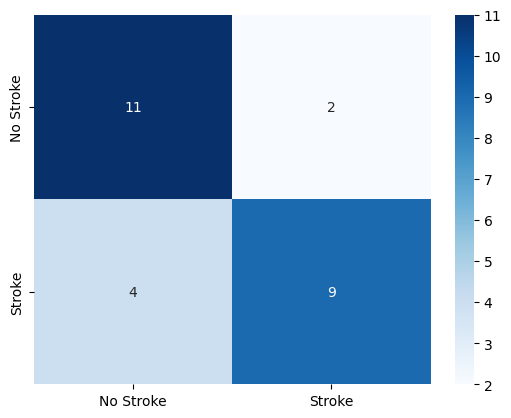

In [26]:
cm = confusion_matrix(y_test, y_pred_new)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])